# MANOVA (Multivariate Analysis of Variance)
### Do group differences exist across a set of outcome variables taken together?
### Used when the dependent variables are conceptually or statistically related.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.multivariate.manova import MANOVA
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Make some dataa
n = 150

df = pd.DataFrame({
    'StudyHours': np.random.normal(6, 2, n).clip(0),
    'Attendance': np.random.normal(90, 5, n).clip(75, 100)
})

#Add correlation between math and reading scores
df['MathScore'] = 50 + 4 * df['StudyHours'] + 0.3 * df['Attendance'] + np.random.normal(0, 5, n)
df['ReadingScore'] = 55 + 2.5 * df['StudyHours'] + 0.4 * df['Attendance'] + np.random.normal(0, 5, n)

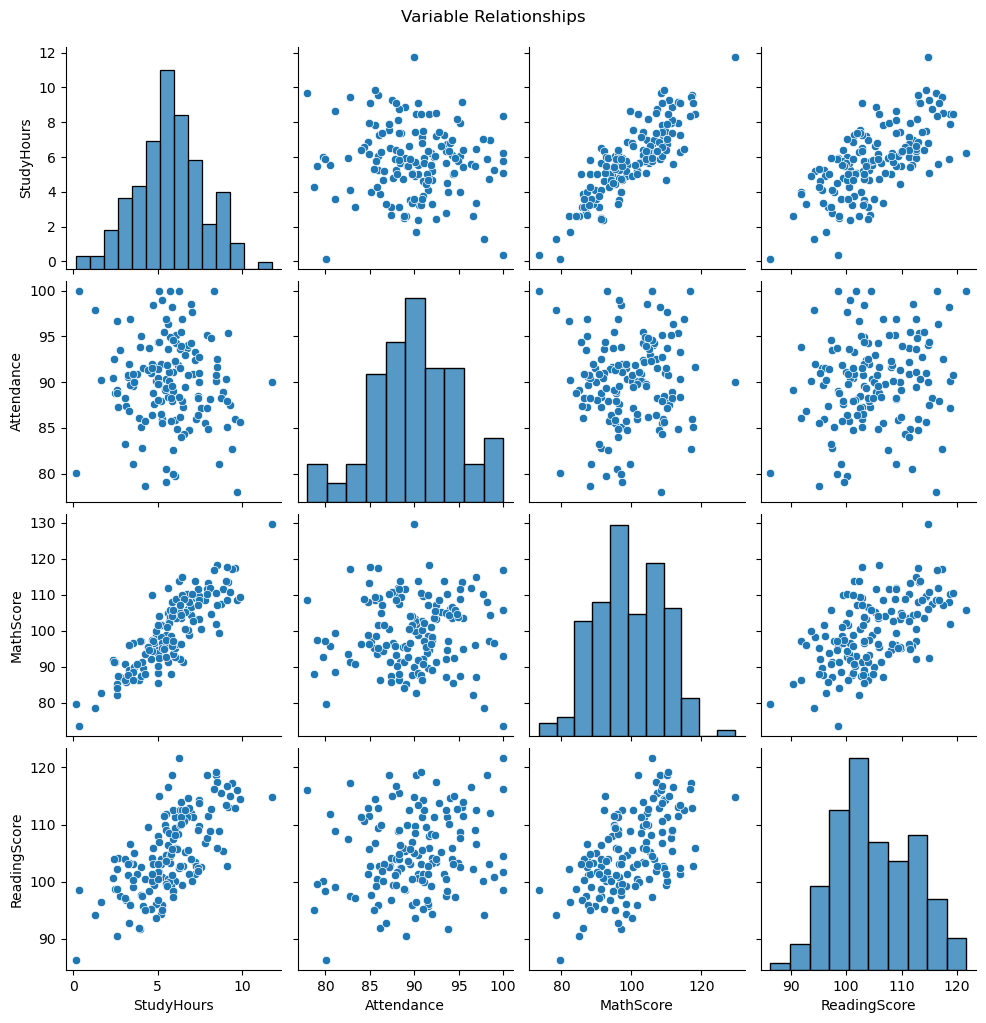

In [13]:
sns.pairplot(df[['StudyHours', 'Attendance', 'MathScore', 'ReadingScore']])
plt.suptitle("Variable Relationships", y=1.02)
plt.show()

In [15]:
#MANOVA Test
maov = MANOVA.from_formula('MathScore + ReadingScore ~ StudyHours + Attendance', data=df)
print(maov.mv_test())

                  Multivariate linear model
                                                              
--------------------------------------------------------------
        Intercept        Value  Num DF  Den DF  F Value Pr > F
--------------------------------------------------------------
           Wilks' lambda 0.5698 2.0000 146.0000 55.1168 0.0000
          Pillai's trace 0.4302 2.0000 146.0000 55.1168 0.0000
  Hotelling-Lawley trace 0.7550 2.0000 146.0000 55.1168 0.0000
     Roy's greatest root 0.7550 2.0000 146.0000 55.1168 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
       StudyHours       Value  Num DF  Den DF  F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.1955 2.0000 146.0000 300.4554 0.0000
         Pillai's trace 0.8045 2.0000 146.0000 300.4554 0.0000
 Hotelling-